In [1]:
import sys
import spikeinterface as si
import matplotlib.pyplot as plt
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.widgets as sw
import spikeinterface.qualitymetrics as sqm
import json
import probeinterface

from probeinterface import Probe, ProbeGroup

import os
import numpy as np
from spikeinterface.core import concatenate_recordings

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
from matplotlib.collections import LineCollection
import scipy
from scipy.sparse.csgraph import connected_components
import pickle

/home/ubuntu/.conda/envs/spike_sorting/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
freq_min = 300  
freq_max = 3000   

recording_raw = se.read_intan('/media/ubuntu/sda/side_works/cen/260130_161001/01_260130_161001.rhs', stream_id='0')
recording_raw = spre.unsigned_to_signed(recording_raw)
recording_raw = spre.resample(recording_raw, 10000)
recording_raw = recording_raw.select_channels(['A-000', 'A-002', 'A-004', 'A-006', 'A-008', 'A-010', 'A-012', 'A-014'])
recording_raw = spre.bandpass_filter(recording_raw, freq_min=freq_min, freq_max=freq_max)
recording_raw = spre.notch_filter(recording_raw, freq=50)
recording_recorded = spre.common_reference(recording_raw)


In [4]:
trigger = se.read_intan('/media/ubuntu/sda/side_works/cen/260130_161001/01_260130_161001.rhs', stream_id = '5')
trigger = spre.unsigned_to_signed(trigger)
trigger = spre.resample(trigger, 10000)
trigger = trigger.get_traces()
trigger = trigger + abs(trigger[:10].mean())

In [5]:
trigger_indices = np.where(trigger > 0.5)[0]
start_indices = trigger_indices[np.concatenate(([True], np.diff(trigger_indices) > 1))]


In [3]:
from probeinterface import write_probeinterface, read_probeinterface

probe_30channel = read_probeinterface('./probe.json')
probe_30channel.set_global_device_channel_indices([i for i in range(8)])
recording_recorded = recording_recorded.set_probegroup(probe_30channel)

In [8]:
output_folder = '/media/ubuntu/sda/side_works/cen/sorted_results/260130'
recording_preprocessed = recording_recorded.save(format="binary", n_jobs = 30)
print(recording_preprocessed)
sorting_kilosort4 = ss.run_sorter(sorter_name="kilosort4", recording=recording_preprocessed, folder=output_folder + "/kilosort4", n_jobs = 30)
analyzer_kilosort4 = si.create_sorting_analyzer(sorting=sorting_kilosort4, recording=recording_preprocessed, format='binary_folder', folder=output_folder + '/analyzer_kilosort4_binary', n_jobs = 30)

extensions_to_compute = [
            "random_spikes",
            "waveforms",
            "noise_levels",
            "templates",
            "spike_amplitudes",
            "unit_locations",
            "spike_locations",
            "correlograms",
            "template_similarity"
        ]

extension_params = {
    "unit_locations": {"method": "center_of_mass"},
    "spike_locations": {"ms_before": 0.1},
    "correlograms": {"bin_ms": 0.1},
    "template_similarity": {"method": "cosine_similarity"}
}

analyzer_kilosort4.compute(extensions_to_compute, extension_params=extension_params)

qm_params = sqm.get_default_qm_params()
analyzer_kilosort4.compute("quality_metrics", qm_params, n_jobs = 30)

import spikeinterface.exporters as sexp
sexp.export_to_phy(analyzer_kilosort4, output_folder + "/phy_folder_for_kilosort", verbose=True, n_jobs = 30)

Use cache_folder=/tmp/spikeinterface_cache/tmpgdnnb58p/LCGB5BYX
write_binary_recording 
engine=process - n_jobs=30 - samples_per_chunk=10,000 - chunk_memory=156.25 KiB - total_memory=4.58 MiB - chunk_duration=1.00s


write_binary_recording (workers: 30 processes): 100%|██████████| 1510/1510 [00:00<00:00, 1596.30it/s]


BinaryFolderRecording: 8 channels - 10000.0Hz - 1 segments - 15,093,674 samples 
                       1,509.37s (25.16 minutes) - int16 dtype - 230.31 MiB


noise_level (no parallelization): 100%|██████████| 20/20 [00:00<00:00, 1724.14it/s]
Compute : spike_amplitudes + spike_locations (no parallelization): 100%|██████████| 1510/1510 [00:00<00:00, 2504.38it/s]
extract PCs (workers: 30 processes): 100%|██████████| 1510/1510 [00:00<00:00, 2794.08it/s]

Run:
phy template-gui  /media/ubuntu/sda/side_works/cen/sorted_results/260130/phy_folder_for_kilosort/params.py


In [9]:
def process_unified_sorting(
    recording_cmr,
    output_folder,
    distance_threshold: float = 10.0,
    similarity_threshold: float = 0.95,
    peak_sign: str= 'neg',
    n_jobs: int = 20,
    verbose: bool = False
):
    from spikeinterface.qualitymetrics import compute_quality_metrics

    sampling_frequency = recording_cmr.get_sampling_frequency()

    if verbose:
        print(f"\n{'='*60}")
        print(f"开始统一处理整个recording的sorting结果")
        print(f"{'='*60}\n")

    # 统一的phy_folder路径
    phy_folder = f'{output_folder}/phy_folder_for_kilosort'

    # 读取整个recording的sorting结果
    if verbose:
        print("读取统一的sorting结果...")
    sorting_curated_phy = se.read_phy(phy_folder, exclude_cluster_groups=["noise", "mua"])
    if verbose:
        print(f"读取到 {len(sorting_curated_phy.unit_ids)} 个units\n")

    # 创建analyzer并计算extensions
    if verbose:
        print("创建analyzer并计算extensions...")
    analyzer_curated_phy = si.create_sorting_analyzer(
        sorting=sorting_curated_phy,
        recording=recording_cmr,
        format='binary_folder',
        folder=output_folder + '/analyzer_curated_temp',
        n_jobs=n_jobs,
        verbose=verbose
    )

    extensions_to_compute = [
        "random_spikes",
        "waveforms",
        "templates",
        "unit_locations",
        "template_similarity"
    ]

    extension_params = {
        "unit_locations": {"method": "center_of_mass"},
        "template_similarity": {"method": "cosine_similarity"}
    }

    analyzer_curated_phy.compute(
        extensions_to_compute,
        extension_params=extension_params,
        n_jobs=n_jobs,
        verbose=verbose
    )
    if verbose:
        print("完成extensions计算\n")

    # 获取neuron信息
    templates_ext = analyzer_curated_phy.get_extension("templates")
    templates_dense = templates_ext.data["average"]
    sparsity = analyzer_curated_phy.sparsity
    unit_locations_ext = analyzer_curated_phy.get_extension("unit_locations")
    unit_locations = unit_locations_ext.get_data()
    channel_locations = analyzer_curated_phy.get_channel_locations()

    # 处理merge逻辑
    if unit_locations.shape[1] >= 2:
        unit_distances = scipy.spatial.distance.cdist(
            unit_locations[:, :2],
            unit_locations[:, :2],
            metric="euclidean"
        )
    else:
        unit_distances = scipy.spatial.distance.cdist(
            unit_locations,
            unit_locations,
            metric="euclidean"
        )

    template_similarity_ext = analyzer_curated_phy.get_extension("template_similarity")
    template_similarity = template_similarity_ext.get_data()

    num_units = len(analyzer_curated_phy.unit_ids)
    pair_mask = np.zeros((num_units, num_units), dtype=bool)

    for i in range(num_units):
        for j in range(i + 1, num_units):
            if unit_distances[i, j] < distance_threshold and template_similarity[i, j] > similarity_threshold:
                pair_mask[i, j] = True
                pair_mask[j, i] = True

    n_components, labels = connected_components(
        csgraph=pair_mask,
        directed=False,
        return_labels=True
    )

    merge_unit_groups = []
    unit_ids_list = analyzer_curated_phy.unit_ids
    for component_id in range(n_components):
        unit_indices = np.where(labels == component_id)[0]
        if len(unit_indices) > 1:
            group = [unit_ids_list[i] for i in unit_indices]
            merge_unit_groups.append(group)

    if len(merge_unit_groups) > 0:
        print(f"发现 {len(merge_unit_groups)} 组需要merge的units，开始merge...")
        analyzer_merged = analyzer_curated_phy.merge_units(
            merge_unit_groups=merge_unit_groups,
            censor_ms=0.3,
            merging_mode="hard",
            new_id_strategy="append",
            format='binary_folder',
            folder=output_folder + '/analyzer_merged',
            verbose=True,
            n_jobs=20
        )
        
        analyzer_merged.compute(extensions_to_compute, extension_params=extension_params, n_jobs=20, verbose = False)
        
        templates_ext_final = analyzer_merged.get_extension("templates")
        templates_dense_final = templates_ext_final.data["average"]
        sparsity_final = analyzer_merged.sparsity
        unit_locations_ext_final = analyzer_merged.get_extension("unit_locations")
        unit_locations_final = unit_locations_ext_final.get_data()
        channel_locations_final = analyzer_merged.get_channel_locations()
        sorting_final = analyzer_merged.sorting
        unit_ids_list_final = analyzer_merged.unit_ids
        
        # 生成position_waveforms
        position_waveforms_final = []
        for unit_id in unit_ids_list_final:
            unit_index = analyzer_merged.sorting.id_to_index(unit_id)
            template_dense_unit = templates_dense_final[unit_index, :, :]
            template_sparse_unit = sparsity_final.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
            sparse_channel_indices = sparsity_final.unit_id_to_channel_indices[unit_id]
            
            if len(sparse_channel_indices) == 0:
                position_waveform = np.zeros(templates_dense_final.shape[1], dtype=templates_dense_final.dtype)
                position_waveforms_final.append(position_waveform)
                continue
            
            sparse_channel_locations = channel_locations_final[sparse_channel_indices, :2]
            unit_location = unit_locations_final[unit_index, :2]
            
            distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
            epsilon = 1e-10
            weights = 1.0 / (distances + epsilon)
            weights = weights / np.sum(weights)
            
            position_waveform = np.dot(template_sparse_unit, weights)
            position_waveforms_final.append(position_waveform)
        
        position_waveforms_final = np.array(position_waveforms_final)
        extremum_channels_final = si.get_template_extremum_channel(
            analyzer_merged, 
            peak_sign=peak_sign,
            outputs="id"
        )
        
        channel_ids_list = list(analyzer_merged.recording.get_channel_ids())
    else:
        print("无需merge units\n")
        # 不需要merge，使用原始结果
        templates_ext_final = analyzer_curated_phy.get_extension("templates")
        templates_dense_final = templates_ext_final.data["average"]
        sparsity_final = analyzer_curated_phy.sparsity
        unit_locations_ext_final = analyzer_curated_phy.get_extension("unit_locations")
        unit_locations_final = unit_locations_ext_final.get_data()
        channel_locations_final = analyzer_curated_phy.get_channel_locations()
        sorting_final = analyzer_curated_phy.sorting
        unit_ids_list_final = unit_ids_list
        
        # 生成position_waveforms
        position_waveforms_final = []
        for unit_id in unit_ids_list_final:
            unit_index = analyzer_curated_phy.sorting.id_to_index(unit_id)
            template_dense_unit = templates_dense_final[unit_index, :, :]
            template_sparse_unit = sparsity_final.sparsify_waveforms(template_dense_unit[np.newaxis, :, :], unit_id)[0]
            sparse_channel_indices = sparsity_final.unit_id_to_channel_indices[unit_id]
            
            if len(sparse_channel_indices) == 0:
                position_waveform = np.zeros(templates_dense_final.shape[1], dtype=templates_dense_final.dtype)
                position_waveforms_final.append(position_waveform)
                continue
            
            sparse_channel_locations = channel_locations_final[sparse_channel_indices, :2]
            unit_location = unit_locations_final[unit_index, :2]
            
            distances = np.sqrt(np.sum((sparse_channel_locations - unit_location[np.newaxis, :])**2, axis=1))
            epsilon = 1e-10
            weights = 1.0 / (distances + epsilon)
            weights = weights / np.sum(weights)
            
            position_waveform = np.dot(template_sparse_unit, weights)
            position_waveforms_final.append(position_waveform)
        
        position_waveforms_final = np.array(position_waveforms_final)
        extremum_channels_final = si.get_template_extremum_channel(
            analyzer_curated_phy, 
            peak_sign=peak_sign,
            outputs="id"
        )
        
        channel_ids_list = list(analyzer_curated_phy.recording.get_channel_ids())

    print("计算每个unit的channel_id...")
    channel_ids_dict = {}  # {unit_id: [contact_id1, contact_id2, ...]}
    for idx, unit_id in enumerate(unit_ids_list_final):
        unit_index = sorting_final.id_to_index(unit_id)
        template_unit = templates_dense_final[unit_index, :, :]  # (n_samples, n_channels)
        
        # 找到template中值不为0的通道
        non_zero_channels = []
        for ch_idx in range(template_unit.shape[1]):  # 遍历channels（最后一个维度）
            if np.any(template_unit[:, ch_idx] != 0):  # 检查该通道在所有时间点的值
                # recording的channel_id已经是contact_id，直接使用
                contact_id = str(channel_ids_list[ch_idx])
                non_zero_channels.append(contact_id)
        
        channel_ids_dict[unit_id] = non_zero_channels

    print(f"完成channel_id计算，共处理{len(channel_ids_dict)}个units\n")

    # 计算channel_snr（每个unit的各个channel的SNR）
    print("计算channel_snr...")
    duration_samples = int(10 * sampling_frequency)  # 10秒
    max_samples = min(duration_samples, recording_cmr.get_num_samples())
    traces = recording_cmr.get_traces(start_frame=0, end_frame=max_samples)  # (n_timepoints, n_channels)

    noise_std_detect = np.median(np.abs(traces) / 0.6745, axis=0)  # (n_channels,)

    all_spike_times = []
    all_spike_unit_ids = []
    for unit_id in unit_ids_list_final:
        spike_train = sorting_final.get_unit_spike_train(unit_id)
        all_spike_times.extend(spike_train.tolist())
        all_spike_unit_ids.extend([unit_id] * len(spike_train))

    n_spikes_total = len(all_spike_times)
    n_spikes_sample = min(1000, n_spikes_total)
    if n_spikes_sample > 0:
        random_indices = np.random.choice(n_spikes_total, size=n_spikes_sample, replace=False)
        sampled_spike_times = [all_spike_times[i] for i in random_indices]
        sampled_spike_unit_ids = [all_spike_unit_ids[i] for i in random_indices]
    else:
        sampled_spike_times = []
        sampled_spike_unit_ids = []

    left_sample = 10
    right_sample = 20
    window_size = left_sample + right_sample

    channel_snr_dict = {} 

    for unit_id in unit_ids_list_final:
        channel_snr_dict[unit_id] = {}
        unit_spike_times = [st for st, uid in zip(sampled_spike_times, sampled_spike_unit_ids) if uid == unit_id]
        
        if len(unit_spike_times) == 0:
            unit_spike_times = sorting_final.get_unit_spike_train(unit_id).tolist()
            if len(unit_spike_times) > 1000:
                unit_spike_times = np.random.choice(unit_spike_times, size=1000, replace=False).tolist()
        
        unit_waveforms = []  # List of (n_channels, window_size)
        valid_spike_times = []
        
        for spike_time in unit_spike_times:
            start = spike_time - left_sample
            end = spike_time + right_sample

            if start < 0:
                start = 0
            if end > recording_cmr.get_num_samples():
                end = recording_cmr.get_num_samples()
            
            waveform = recording_cmr.get_traces(start_frame=start, end_frame=end)  # (n_timepoints, n_channels)
            unit_waveforms.append(waveform)
            valid_spike_times.append(spike_time)
        
        if len(unit_waveforms) == 0:
            continue
        
        unit_waveforms = np.array(unit_waveforms)  # (n_spikes, n_timepoints, n_channels)
        
        spike_time_values = unit_waveforms[:, left_sample, :]  # (n_spikes, n_channels) - 每个spike在spike_time时刻各个channel的值
        
        channel_amplitudes = np.mean(spike_time_values, axis=0)  # (n_channels,) - 每个channel的平均值（在spike_time时刻）
        channel_snr = np.abs(channel_amplitudes) / noise_std_detect  # (n_channels,)
        
        unit_channel_ids = channel_ids_dict.get(unit_id, [])  # 获取该unit的channel_id列表
        
        for ch_idx, snr_value in enumerate(channel_snr):
            channel_id = str(channel_ids_list[ch_idx])
            if channel_id in unit_channel_ids:
                channel_snr_dict[unit_id][channel_id] = float(snr_value)

    print(f"完成channel_snr计算，共处理{len(channel_snr_dict)}个units\n")

    # 创建channel_id到索引的映射
    channel_id_to_idx = {str(ch_id): idx for idx, ch_id in enumerate(channel_ids_list)}

    # 计算每个unit的sign（根据extremum_channel处template的极值）
    unit_signs = {}
    for idx, unit_id in enumerate(unit_ids_list_final):
        extremum_channel = extremum_channels_final[unit_id]
        extremum_channel_str = str(extremum_channel)

        # 获取extremum_channel对应的索引
        if extremum_channel_str in channel_id_to_idx:
            ch_idx = channel_id_to_idx[extremum_channel_str]
            template_unit = templates_dense_final[idx, :, ch_idx]  # (n_samples,)

            # 计算template在该通道的极值
            template_min = np.min(template_unit)
            template_max = np.max(template_unit)

            # 判断极值符号：比较绝对值
            if np.abs(template_max) >= np.abs(template_min):
                unit_signs[unit_id] = 1  # 正极值
            else:
                unit_signs[unit_id] = -1  # 负极值
        else:
            # 如果找不到对应的channel，默认设为-1
            unit_signs[unit_id] = -1

    neuron_inf_all = {}
    for idx, unit_id in enumerate(unit_ids_list_final):
        neuron_inf_all[unit_id] = {
            'location_x': float(unit_locations_final[idx, 0]),
            'location_y': float(unit_locations_final[idx, 1]),
            'position_waveform': position_waveforms_final[idx],
            'extremum_channel': extremum_channels_final[unit_id],
            'sign': unit_signs[unit_id],
            'channel_id': channel_ids_dict[unit_id],
            'channel_snr': channel_snr_dict.get(unit_id, {})
        }

    print("生成整体的gt_detect_array...")
    spike_vector_final = sorting_final.to_spike_vector()
    gt_detect_data_all = []

    for spike in spike_vector_final:
        unit_index = spike['unit_index']
        unit_id = sorting_final.unit_ids[unit_index]        
        sample_index = spike['sample_index']

        extremum_channel = extremum_channels_final[unit_id]
        
        gt_detect_data_all.append({
            'time': sample_index,
            'unit_id': unit_id,
            'extremum_channel': str(extremum_channel),
        })

    gt_detect_array_all = pd.DataFrame(gt_detect_data_all)

    if verbose:
        print("保存neuron_inf_all和gt_detect_array_all...")
    with open(output_folder + '/neuron_inf_all.pickle', 'wb') as f:
        pickle.dump(neuron_inf_all, f)
    gt_detect_array_all.to_csv(output_folder + '/gt_detect_array_all.csv', index=False)
    if verbose:
        print(f"已保存到: {output_folder}/neuron_inf_all.pickle 和 {output_folder}/gt_detect_array_all.csv\n")

    if len(merge_unit_groups) > 0:
        analyzer_final = analyzer_merged
    else:
        analyzer_final = analyzer_curated_phy

    return neuron_inf_all, gt_detect_array_all, analyzer_final

In [14]:
neuron_inf_all, gt_detect_array_all, analyzer = process_unified_sorting(
        recording_cmr=recording_recorded,
        output_folder=output_folder ,
        distance_threshold=10.0,
        similarity_threshold=0.95,
        peak_sign='both',
        n_jobs=30,
        verbose=True
    )


开始统一处理整个recording的sorting结果

读取统一的sorting结果...
读取到 7 个units

创建analyzer并计算extensions...
estimate_sparsity 
engine=process - n_jobs=30 - samples_per_chunk=10,000 - chunk_memory=156.25 KiB - total_memory=4.58 MiB - chunk_duration=1.00s


estimate_sparsity (workers: 30 processes): 100%|██████████| 1510/1510 [00:00<00:00, 5331.64it/s]


compute_waveforms 
engine=process - n_jobs=30 - samples_per_chunk=10,000 - chunk_memory=156.25 KiB - total_memory=4.58 MiB - chunk_duration=1.00s


compute_waveforms (workers: 30 processes): 100%|██████████| 1510/1510 [00:05<00:00, 301.36it/s]


完成extensions计算

发现 1 组需要merge的units，开始merge...
compute_waveforms 
engine=process - n_jobs=20 - samples_per_chunk=10,000 - chunk_memory=156.25 KiB - total_memory=3.05 MiB - chunk_duration=1.00s


compute_waveforms (workers: 20 processes): 100%|██████████| 1510/1510 [00:06<00:00, 216.34it/s]


计算每个unit的channel_id...
完成channel_id计算，共处理6个units

计算channel_snr...
完成channel_snr计算，共处理6个units

生成整体的gt_detect_array...
保存neuron_inf_all和gt_detect_array_all...
已保存到: /media/ubuntu/sda/side_works/cen/sorted_results/260130/neuron_inf_all.pickle 和 /media/ubuntu/sda/side_works/cen/sorted_results/260130/gt_detect_array_all.csv



In [17]:
# 统计每一个trial每一个neuron前后5s的spike数量，得到(n_neuron, n_trial, 2)的csv
import pandas as pd
import numpy as np

# 采样频率
fs = 10000  # Hz
window_before = 5.0  # 5秒
window_after = 5.0   # 5秒
window_before_samples = int(window_before * fs)
window_after_samples = int(window_after * fs)

# 获取units列表
unit_ids = list(neuron_inf_all.keys())
n_units = len(unit_ids)
n_trials = len(start_indices)

# 获取每个unit的spike train
spike_trains = {}
for unit_id in unit_ids:
    spike_train = analyzer.sorting.get_unit_spike_train(unit_id)
    spike_trains[unit_id] = spike_train

# 创建数据存储
# spike_counts[unit_idx, trial_idx, 0] = 前5s的spike数量
# spike_counts[unit_idx, trial_idx, 1] = 后5s的spike数量
spike_counts = np.zeros((n_units, n_trials, 2), dtype=int)

for unit_idx, unit_id in enumerate(unit_ids):
    spike_train = spike_trains[unit_id]
    
    for trial_idx, start_idx in enumerate(start_indices):
        # 前5s窗口
        window_start_before = start_idx - window_before_samples
        window_end_before = start_idx  # 不包含trigger时刻
        
        # 后5s窗口
        window_start_after = start_idx
        window_end_after = start_idx + window_after_samples  # 不包含trigger时刻
        
        # 统计前5s的spikes
        mask_before = (spike_train >= window_start_before) & (spike_train < window_end_before)
        spike_counts[unit_idx, trial_idx, 0] = np.sum(mask_before)
        
        # 统计后5s的spikes
        mask_after = (spike_train > window_start_after) & (spike_train <= window_end_after)
        spike_counts[unit_idx, trial_idx, 1] = np.sum(mask_after)

# 创建DataFrame保存结果
# 格式: unit_id, trial, spikes_before_5s, spikes_after_5s
results_list = []
for unit_idx, unit_id in enumerate(unit_ids):
    for trial_idx in range(n_trials):
        results_list.append({
            'unit_id': unit_id,
            'trial': trial_idx + 1,  # trial编号从1开始
            'spikes_before_5s': spike_counts[unit_idx, trial_idx, 0],
            'spikes_after_5s': spike_counts[unit_idx, trial_idx, 1]
        })

spike_counts_df = pd.DataFrame(results_list)

# 保存到csv
output_file = output_folder + '/spike_counts_per_trial.csv'
spike_counts_df.to_csv(output_file, index=False)


In [19]:
# 将neuron_inf_all转换成DataFrame并保存为csv
import pandas as pd
import numpy as np

# 获取unit_ids
unit_ids = list(neuron_inf_all.keys())

# 创建列表存储所有数据
data_list = []

for unit_id in unit_ids:
    unit_info = neuron_inf_all[unit_id]
    
    row = {
        'unit_id': unit_id,
        'location_x': unit_info['location_x'],
        'location_y': unit_info['location_y'],
        'extremum_channel': unit_info['extremum_channel'],
        'sign': unit_info['sign']
    }
    
    # 将channel_id列表转换为字符串（逗号分隔）
    if isinstance(unit_info['channel_id'], list):
        row['channel_id'] = ','.join([str(ch) for ch in unit_info['channel_id']])
    else:
        row['channel_id'] = unit_info['channel_id']
    
    # 将channel_snr字典转换为字符串（格式：ch:value）
    if isinstance(unit_info['channel_snr'], dict):
        snr_items = [f"{ch}:{val}" for ch, val in unit_info['channel_snr'].items()]
        row['channel_snr'] = ','.join(snr_items)
    else:
        row['channel_snr'] = unit_info['channel_snr']
    
    # position_waveform是数组，保存为字符串
    if isinstance(unit_info['position_waveform'], np.ndarray):
        row['position_waveform'] = ','.join([str(x) for x in unit_info['position_waveform']])
    else:
        row['position_waveform'] = unit_info['position_waveform']
    
    data_list.append(row)

# 创建DataFrame
neuron_inf_df = pd.DataFrame(data_list)

# 设置unit_id为索引
neuron_inf_df = neuron_inf_df.set_index('unit_id')

# 保存到csv
output_file = output_folder + '/neuron_inf_all.csv'
neuron_inf_df.to_csv(output_file)


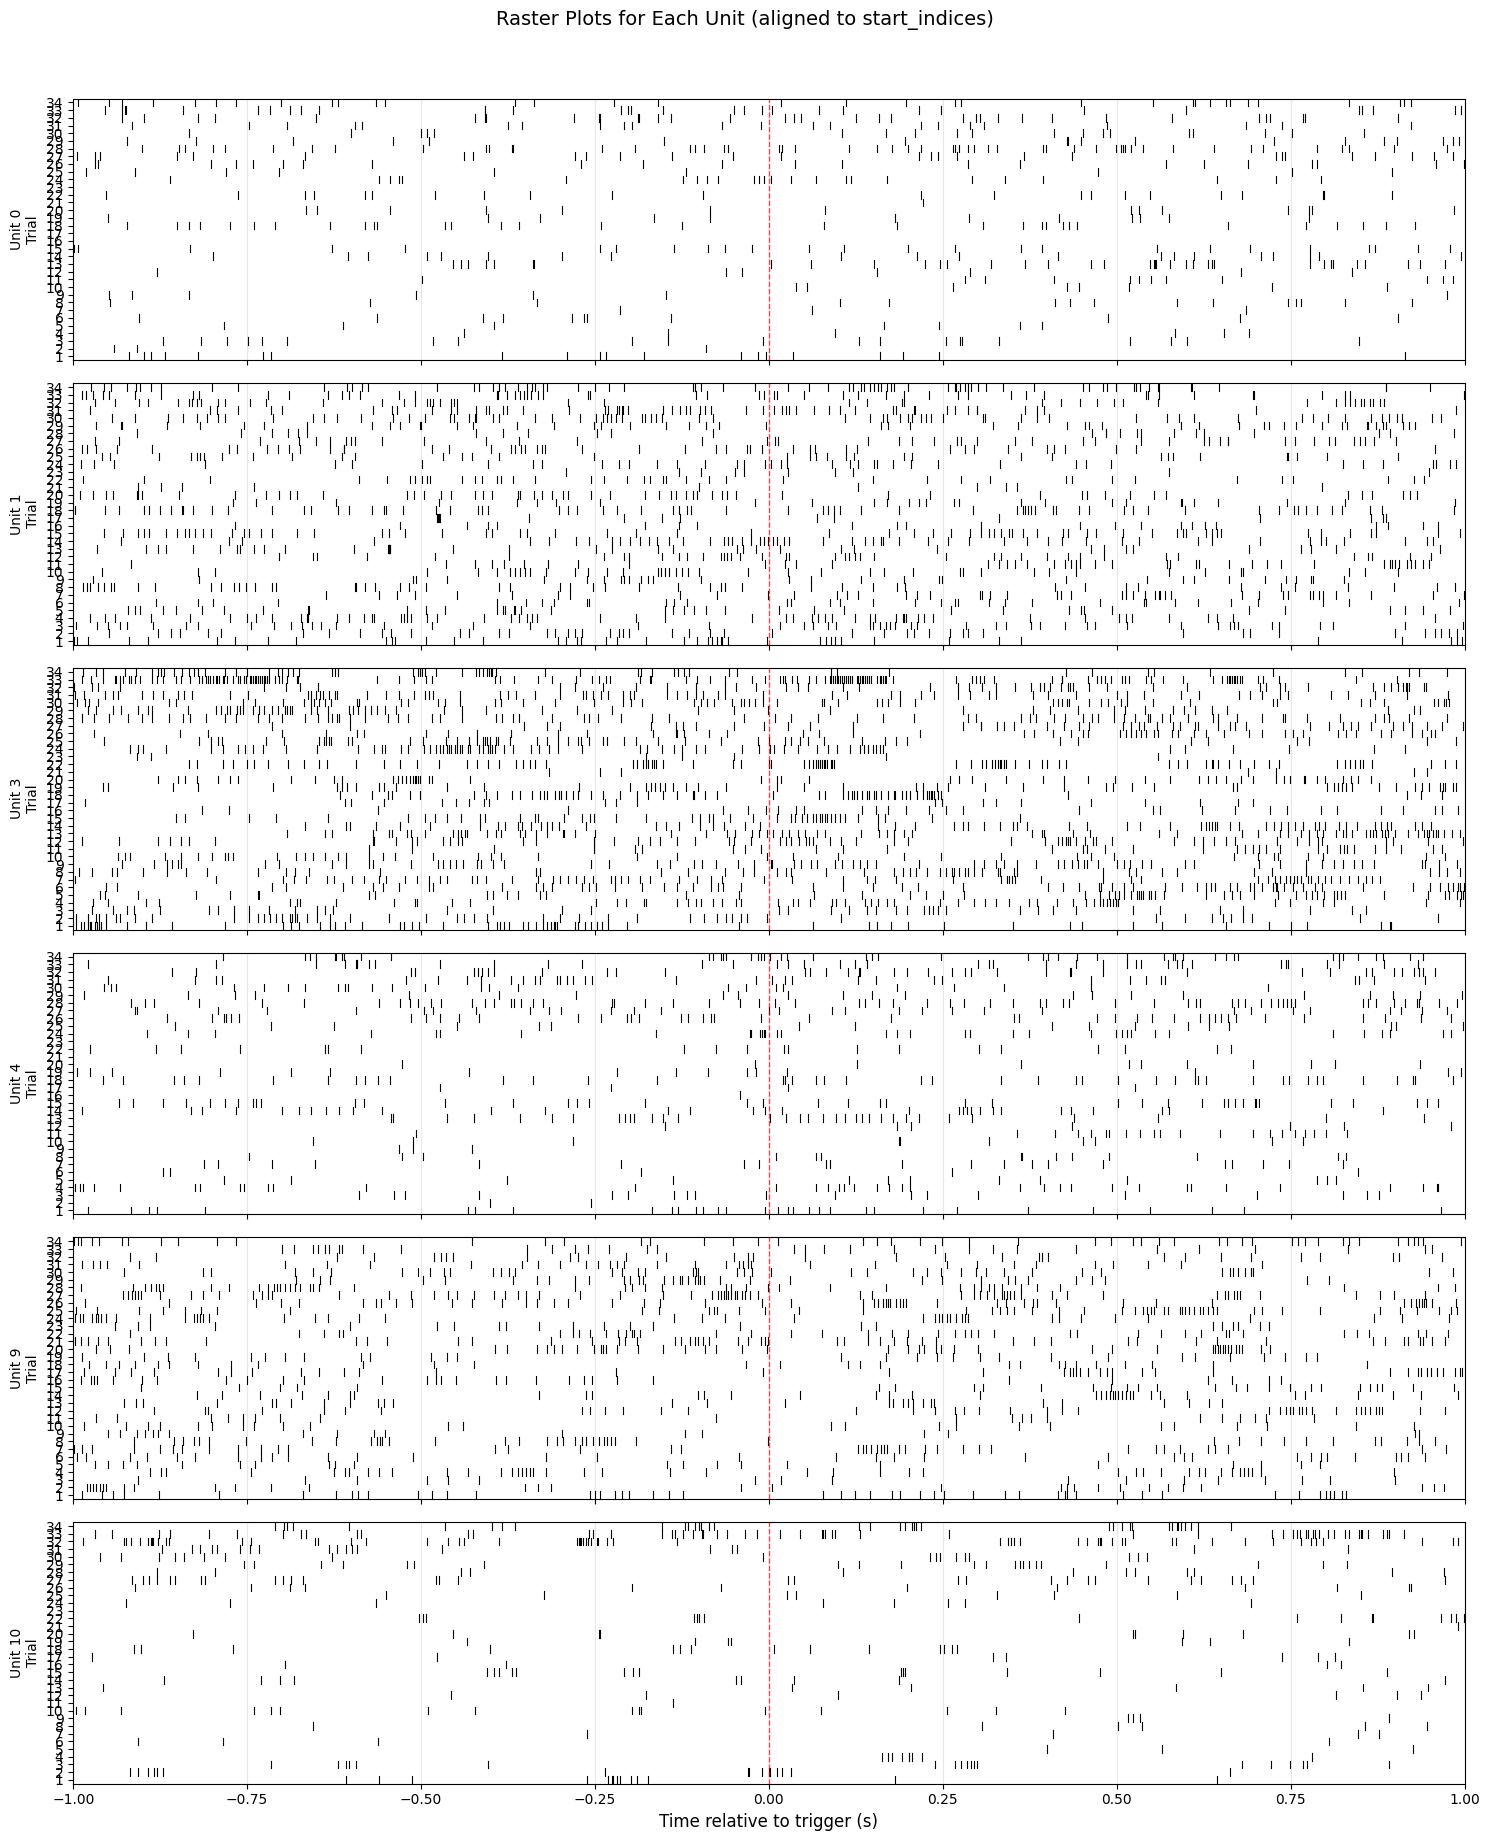

Raster plots已保存到: /media/ubuntu/sda/side_works/cen/sorted_results/260130/raster_plots_per_unit.png


In [16]:
# 为每个neuron_inf中的unit绘制raster plot，每个start_indices为一行，前后1s
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
import pickle

# 加载neuron_inf_all
output_folder = '/media/ubuntu/sda/side_works/cen/sorted_results/260130'
with open(output_folder + '/neuron_inf_all.pickle', 'rb') as f:
    neuron_inf_all = pickle.load(f)

# 获取units列表
unit_ids = list(neuron_inf_all.keys())
n_units = len(unit_ids)

# 采样频率
fs = 10000  # Hz
window_before = 1.0  # 1秒
window_after = 1.0   # 1秒
window_before_samples = int(window_before * fs)
window_after_samples = int(window_after * fs)

# 获取每个unit的spike train
spike_trains = {}
for unit_id in unit_ids:
    spike_train = analyzer.sorting.get_unit_spike_train(unit_id)
    spike_trains[unit_id] = spike_train

# 创建raster plots
fig, axes = plt.subplots(n_units, 1, figsize=(15, 3 * n_units), sharex=True)

if n_units == 1:
    axes = [axes]

for idx, unit_id in enumerate(unit_ids):
    ax = axes[idx]
    spike_train = spike_trains[unit_id]
    
    # 为每个start_indices绘制一行
    for i, start_idx in enumerate(start_indices):
        # 找到在该时间窗口内的spikes
        window_start = start_idx - window_before_samples
        window_end = start_idx + window_after_samples
        
        # 筛选在窗口内的spikes
        mask = (spike_train >= window_start) & (spike_train <= window_end)
        spikes_in_window = spike_train[mask]
        
        # 转换为相对于start_idx的时间（秒）
        relative_times = (spikes_in_window - start_idx) / fs
        
        # 绘制raster（每个spike为一条竖线）
        for rel_time in relative_times:
            ax.plot([rel_time, rel_time], [i - 0.5, i + 0.5], 'k-', linewidth=0.8)
    
    # 设置y轴
    ax.set_ylim(-0.5, len(start_indices) - 0.5)
    ax.set_ylabel(f'Unit {unit_id}\nTrial', fontsize=10)
    ax.set_yticks(range(len(start_indices)))
    ax.set_yticklabels([str(i+1) for i in range(len(start_indices))])
    
    # 添加0线（trigger时刻）
    ax.axvline(x=0, color='r', linestyle='--', linewidth=1, alpha=0.7)
    
    # 添加网格
    ax.grid(True, axis='x', alpha=0.3)

# 设置x轴标签
axes[-1].set_xlabel('Time relative to trigger (s)', fontsize=12)
axes[-1].set_xlim(-window_before, window_after)

# 添加总标题
fig.suptitle('Raster Plots for Each Unit (aligned to start_indices)', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig(output_folder + '/raster_plots_per_unit.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Raster plots已保存到: {output_folder}/raster_plots_per_unit.png")